# 4 · Results: reproduction vs. paper

This notebook gathers the cached runs (created by notebook 3 or by
`python scripts/run_experiments.py --fv FV1 FV2`) and compares them with the paper's
Tables 10–13 and Figures 3–5.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drbasem/Outdoor_Localization_Based_on_LoRa_Networks/blob/claude/keen-hamilton-7kcqml/notebooks/04_results.ipynb)

In [1]:
# ▶ Run this cell first. On your own computer it does nothing; on Google Colab it downloads the
#   code and the dataset (about 1-2 minutes the first time).
import os, sys, subprocess
if "google.colab" in sys.modules:
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "--depth", "1", "-b", "claude/keen-hamilton-7kcqml", "https://github.com/drbasem/Outdoor_Localization_Based_on_LoRa_Networks", "/content/repo"], check=True)
    os.chdir("/content/repo/notebooks")
    subprocess.run([sys.executable, "../scripts/download_data.py", "--json"], check=True)
print("working folder:", os.getcwd())

working folder: /home/user/Outdoor_Localization_Based_on_LoRa_Networks/notebooks


In [2]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `lora_loc` importable from notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lora_loc import config, data, preprocessing as pp, features, geo, plotting
plotting.style()
pd.set_option("display.precision", 2)
from lora_loc import models, experiment, paper_results as paper
res = experiment.collect()
res = res.set_index(["fv", "model"]).sort_index()
available_fvs = sorted(res.index.get_level_values(0).unique(), key=lambda s: int(s[2:]))
print("feature vectors with results:", available_fvs)

feature vectors with results: ['FV1', 'FV2']


## 4.1 Mean error per feature vector (Tables 10–11)

In [3]:
rows = []
for fv in available_fvs:
    for name in models.MODEL_NAMES:
        if (fv, name) in res.index:
            ours = res.loc[(fv, name), "mean_m"]; ref = paper.MEAN_ERROR_M.loc[name, fv]
            rows.append({"FV": fv, "model": name, "ours (m)": ours, "paper (m)": ref,
                         "Δ (m)": ours - ref, "Δ (%)": 100 * (ours - ref) / ref})
cmp = pd.DataFrame(rows).set_index(["FV", "model"])
display(cmp.round(2))
print("mean |Δ| per FV (m):"); print(cmp["Δ (m)"].abs().groupby(level=0).mean().round(2).to_string())

ours (m)  paper (m)  Δ (m)  Δ (%)
FV  model                                      
FV1 k-NN        336.51     338.56  -2.05  -0.60
    CNN         354.01     343.88  10.13   2.95
    SVR         334.35     331.92   2.43   0.73
    ANN         354.43     332.74  21.69   6.52
    XGBoost     328.30     327.66   0.64   0.20
    LightGBM    326.75     325.43   1.32   0.41
    Hybrid      327.64     323.38   4.26   1.32
FV2 k-NN        331.74     326.26   5.48   1.68
    CNN         343.34     341.39   1.95   0.57
    SVR         376.22     321.93  54.29  16.86
    ANN         347.11     329.84  17.27   5.24
    XGBoost     320.11     318.95   1.16   0.36
    LightGBM    317.19     316.59   0.60   0.19
    Hybrid      320.99     314.21   6.78   2.16

mean |Δ| per FV (m):
FV
FV1     6.07
FV2    12.50


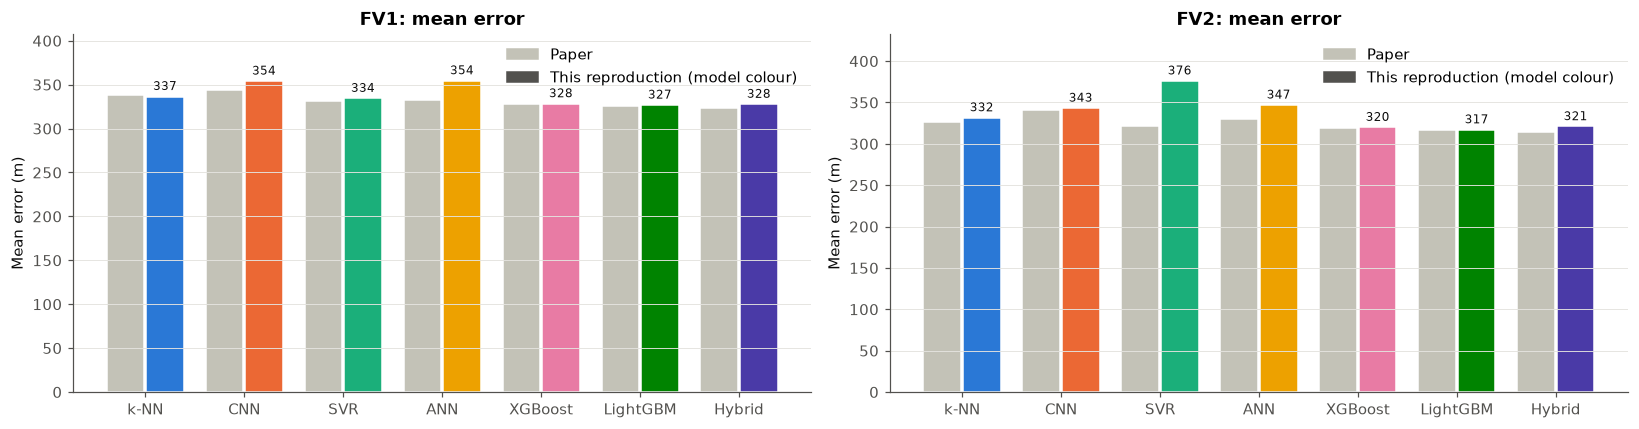

In [4]:
fig, axes = plt.subplots(1, len(available_fvs), figsize=(7.5 * len(available_fvs), 4), squeeze=False)
for ax, fv in zip(axes[0], available_fvs):
    ours = res.loc[fv, "mean_m"]
    plotting.compare_bars(ours, paper.MEAN_ERROR_M[fv], ax=ax, title=f"{fv}: mean error")
    ax.set_ylim(0, max(ours.max(), 350) * 1.15)
plt.tight_layout(); plt.show()

## 4.2 Error distributions (Fig. 3, Table 12)

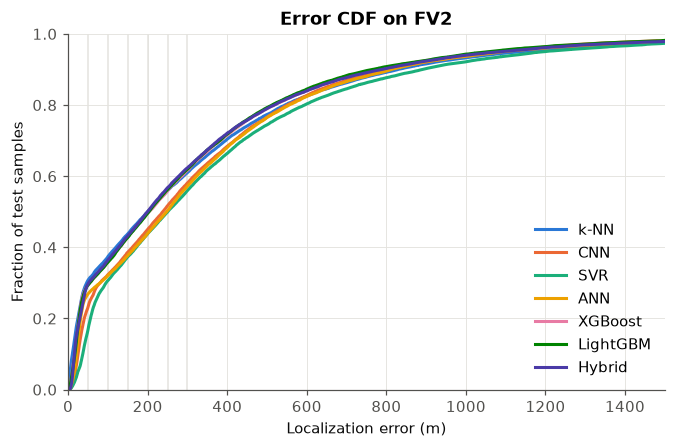

Reproduced, FV2 (fraction of test samples):


,≤50 m,≤100 m,≤150 m,≤200 m,≤250 m,≤300 m
model,,,,,,
ANN,27,32,38,44,50,57
CNN,23,32,39,45,52,58
Hybrid,30,36,43,50,57,62
LightGBM,29,36,43,50,56,62
SVR,17,31,37,44,50,56
XGBoost,29,36,43,50,56,62
k-NN,31,37,44,50,56,61


Paper Table 12 (best FV per model, mostly FV4/FV15/FV16 — not directly comparable):


,50,100,150,200,250,300
k-NN,33,41,48,55,61,66
CNN,3,25,40,47,54,61
SVR,15,35,43,40,57,63
ANN,28,37,45,53,60,66
XGBoost,32,42,50,58,65,71
LightGBM,32,41,50,59,65,71
Hybrid,34,44,52,60,66,72


In [5]:
best_fv = available_fvs[-1]
errs = {name: experiment.run(name, best_fv, verbose=False)["errors_m"]
        for name in models.MODEL_NAMES if (best_fv, name) in res.index}
plotting.cdf(errs, xmax=1500, thresholds=config.CDF_THRESHOLDS_M)
plt.title(f"Error CDF on {best_fv}"); plt.show()

cols = [f"within_{t}m" for t in config.CDF_THRESHOLDS_M]
tab = res.loc[best_fv, cols].copy(); tab.columns = [f"≤{t} m" for t in config.CDF_THRESHOLDS_M]
print(f"Reproduced, {best_fv} (fraction of test samples):"); display((tab * 100).round(0).astype(int))
print("Paper Table 12 (best FV per model, mostly FV4/FV15/FV16 — not directly comparable):")
display((paper.CDF_TABLE12 * 100).round(0).astype(int))

Summary statistics. The paper's Eq. 20 SD is the population SD of the per-sample errors.

In [6]:
stats = res[["mean_m", "median_m", "sd_m", "p90_m", "max_m", "r2_lat", "r2_lon"]]
display(stats.round(3))

mean_m  median_m    sd_m   p90_m    max_m  r2_lat  r2_lon
fv  model                                                              
FV1 ANN       354.43    248.34  392.32  820.51  4989.81    0.94    0.89
    CNN       354.01    244.89  386.32  820.86  4661.02    0.95    0.89
    Hybrid    327.64    202.02  402.34  807.18  5295.01    0.95    0.89
    LightGBM  326.75    210.55  394.75  790.19  5049.31    0.95    0.89
    SVR       334.35    204.88  394.86  806.29  5055.38    0.95    0.89
    XGBoost   328.30    207.52  398.18  802.10  5021.10    0.95    0.89
    k-NN      336.51    207.01  414.76  835.07  5148.18    0.94    0.88
FV2 ANN       347.11    247.70  392.18  812.14  4973.39    0.95    0.89
    CNN       343.34    237.87  385.95  799.09  4669.20    0.95    0.89
    Hybrid    320.99    199.59  399.89  789.40  5303.40    0.95    0.89
    LightGBM  317.19    203.22  387.02  765.18  5232.70    0.95    0.90
    SVR       376.21    250.34  426.91  890.03  5364.37    0.94    0.86
    XGBoost   320.11    203.57  390.80  781.96  5198.80    0.95    0.90
    k-NN      331.74    199.53  417.52  829.39  5147.12    0.94    0.88

## 4.3 Where are the errors? (Fig. 4)

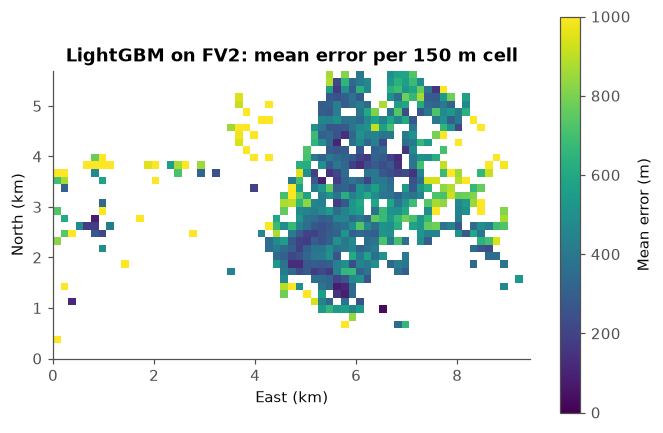

{'cells_below_250m': '10.5%', 'cells_below_300m': '19.5%', 'cells_below_350m': '28.6%'}
paper (Hybrid, best FV): 21.7% of cells < 250 m, 33% < 300 m, 42.6% < 350 m


In [7]:
best = res.loc[best_fv, "mean_m"].idxmin()
r = experiment.run(best, best_fv, verbose=False)
ax, share = plotting.error_heatmap(r["y_true_deg"], r["errors_m"], cell_m=150)
ax.set_title(f"{best} on {best_fv}: mean error per 150 m cell"); plt.show()
print({k: f"{v:.1%}" for k, v in share.items()})
print("paper (Hybrid, best FV): 21.7% of cells < 250 m, 33% < 300 m, 42.6% < 350 m")

Large errors cluster on the periphery of the covered area, most visibly in the sparsely
sampled western part. There, few training fingerprints exist and messages are often heard by a
single gateway. The dense city centre has the lowest errors.

The paper's cell statistics (21.7 % / 33 % / 42.6 % of cells below 250 / 300 / 350 m) are for
the Hybrid on its best FV (FV4, mean 244.5 m), so they are not directly comparable with an
FV1/FV2 map.

## 4.4 Inference time (Fig. 5)
Per-sample prediction time, measured by predicting one sample at a time on 200 random test
samples. Absolute numbers depend on the hardware. Our CPU is not the authors' machine, so compare
the **ranking**, not the values.

In [8]:
t = res.loc[best_fv, ["infer_single_mean_s", "infer_batched_s", "train_s"]].copy()
t["paper per-sample (s)"] = pd.Series(paper.INFERENCE_S)
display(t.rename(columns={"infer_single_mean_s": "ours per-sample (s)",
                          "infer_batched_s": "ours batched, per sample (s)",
                          "train_s": "ours training (s)"}).round(5))

,ours per-sample (s),"ours batched, per sample (s)",ours training (s),paper per-sample (s)
model,,,,
ANN,7.22e-02,1.00e-05,1.86e+02,5.68e-02
CNN,7.11e-02,1.00e-05,1.60e+03,1.49e-01
Hybrid,6.21e-02,1.00e-05,9.82e+02,3.00e-01
LightGBM,2.76e-03,1.40e-04,2.30e+01,2.46e-03
SVR,1.11e-02,8.97e-03,7.49e+02,1.13e-02
XGBoost,1.85e-03,1.00e-05,6.01e+01,9.60e-04
k-NN,2.20e-03,9.20e-04,2.68e-03,1.06e-02


## 4.5 All 16 feature vectors (JSON release, paper Tables 10–11)

The paper builds every feature vector from the JSON release. Running
`python scripts/run_experiments.py --source json --fv FV1 … FV16 --models k-NN XGBoost LightGBM ANN`
caches the results in `results/runs_json/`. The cell below trains whatever is missing, which is
fast for k-NN / XGBoost / LightGBM and takes a few minutes per FV for the ANN.

In [9]:
json_dir = config.RESULTS_DIR / "runs_json"
ALL_FV = [f"FV{i}" for i in range(1, 17)]
if config.JSON_FILE.exists():
    for fv in ALL_FV:
        d = experiment.prepare_fv(fv, source="json")
        for name in ["k-NN", "XGBoost", "LightGBM", "ANN"]:
            experiment.run(name, fv, prepared=d, runs_dir=json_dir, verbose=False, metrics_only=True)
rj = experiment.collect(json_dir)
if rj.empty:
    print("No JSON results: put lorawan_antwerp_2019_dataset.json.txt in data/ and re-run.")
else:
    ours = rj.pivot(index="model", columns="fv", values="mean_m")
    ours = ours[[f for f in ALL_FV if f in ours.columns]]
    delta = ours - paper.MEAN_ERROR_M.loc[ours.index, ours.columns]
    print("Reproduced mean error (m):"); display(ours.round(1))
    print("Δ = ours − paper (m):"); display(delta.round(1))

Reproduced mean error (m):


fv,FV1,FV2,FV3,FV4,FV5,FV6,FV7,FV8,FV9,FV10,FV11,FV12,FV13,FV14,FV15,FV16
model,,,,,,,,,,,,,,,,
ANN,369.0,349.3,355.4,325.9,359.0,331.0,338.0,320.5,316.6,316.6,309.8,307.1,300.6,306.9,282.4,285.4
CNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,337.7,NaN
Hybrid,NaN,NaN,NaN,259.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,324.3,314.8,314.8,253.4,314.8,255.0,255.2,253.2,309.8,309.8,306.1,304.8,305.3,305.4,248.3,248.3
SVR,NaN,NaN,NaN,384.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,327.0,318.1,318.1,247.1,318.0,250.7,250.1,248.2,312.5,311.5,309.3,307.4,308.4,307.8,249.2,251.0
k-NN,334.4,330.9,350.2,295.6,332.5,328.9,334.6,298.5,316.2,314.7,313.1,310.0,308.2,310.0,282.8,284.0


Δ = ours − paper (m):


fv,FV1,FV2,FV3,FV4,FV5,FV6,FV7,FV8,FV9,FV10,FV11,FV12,FV13,FV14,FV15,FV16
model,,,,,,,,,,,,,,,,
ANN,36.3,19.5,35.6,10.6,40.7,27.5,32.0,13.1,8.4,5.8,6.2,4.4,-7.2,6.6,-3.4,5.7
CNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.2,NaN
Hybrid,NaN,NaN,NaN,14.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,-1.1,-1.8,-0.3,0.6,-1.2,0.4,-0.1,1.7,-1.8,-1.7,-1.1,-1.1,-1.1,-0.4,-1.9,-1.2
SVR,NaN,NaN,NaN,63.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,-0.6,-0.8,-0.9,-1.6,-0.9,0.3,-1.3,-1.2,-1.2,-1.9,0.4,-1.2,-0.9,-1.1,-0.5,-0.0
k-NN,-4.1,4.7,17.6,4.2,3.5,23.8,25.5,3.4,0.2,-3.0,1.5,-2.5,-0.7,1.3,-1.8,-1.7


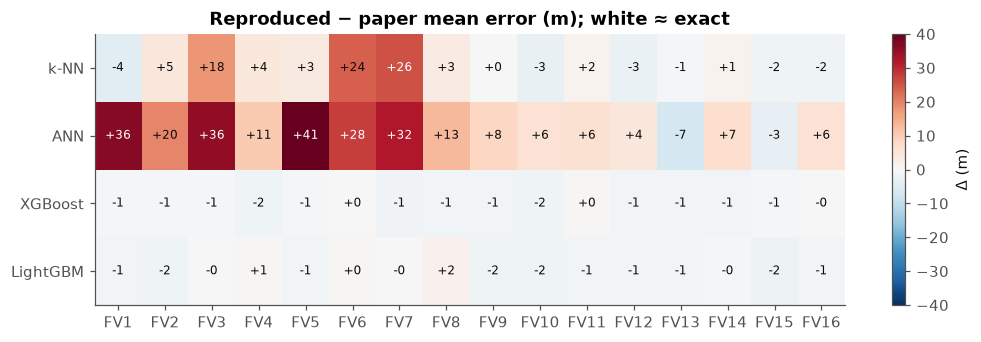

In [10]:
if not rj.empty:
    models4 = [m for m in ["k-NN", "ANN", "XGBoost", "LightGBM"] if m in delta.index]
    fig, ax = plt.subplots(figsize=(11, 3.2))
    im = ax.imshow(delta.loc[models4].to_numpy(dtype=float), cmap="RdBu_r", vmin=-40, vmax=40, aspect="auto")
    ax.set_xticks(range(delta.shape[1]), delta.columns); ax.set_yticks(range(len(models4)), models4)
    for i, m in enumerate(models4):
        for j, fv in enumerate(delta.columns):
            v = delta.loc[m, fv]
            if pd.notna(v): ax.text(j, i, f"{v:+.0f}", ha="center", va="center", fontsize=8,
                                    color="white" if abs(v) > 25 else plotting.INK)
    ax.grid(False); ax.set_title("Reproduced − paper mean error (m); white ≈ exact")
    plt.colorbar(im, ax=ax, label="Δ (m)"); plt.show()

**Reading the heatmap.**
* **XGBoost and LightGBM are within 2 m of the paper on every feature vector.** The paper's
  feature-vector study therefore reproduces for the tree models.
* For XGBoost this needs `tree_method="exact"`. With the 256-bin histogram default of
  XGBoost ≥ 2.0, the frame counter (values up to 199,164) is coarsened, and the CNT feature
  vectors come out about 20 m worse. This is a good example of how a library default can quietly
  change a published result.
* k-NN is off only where the channel index enters a Manhattan distance (FV3, FV6, FV7).
* The ANN is the least stable model: it is 11–41 m worse on FV1–FV8 and close on FV9–FV16.

## 4.6 Do the results survive a stricter split? (beyond the paper)

`python scripts/split_check.py` retrains LightGBM under three protocols:
**random** (the paper's), **chronological** (train on the earliest 70 % of messages, test on the
latest 15 %), and **unseen devices** (whole vehicles held out).

split,random,chronological,device
fv,,,
FV1,324.3,286.2,573.4
FV2,314.8,279.5,574.1
FV4,253.4,555.0,775.1
FV9,309.8,272.5,561.8
FV13,305.3,270.0,563.3
FV15,248.3,327.2,665.9
FV16,248.3,326.1,664.4


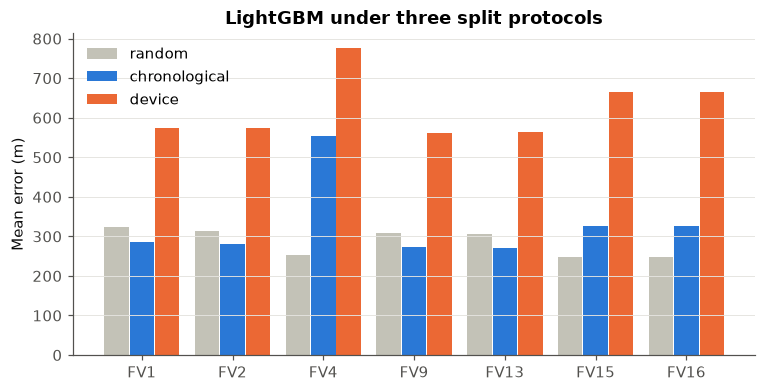

In [11]:
sc_file = config.RESULTS_DIR / "split_check.csv"
if sc_file.exists():
    sc = pd.read_csv(sc_file)
    tab = sc.pivot(index="fv", columns="split", values="mean_m")
    tab = tab.loc[[f for f in ALL_FV if f in tab.index], ["random", "chronological", "device"]]
    display(tab.round(1))
    fig, ax = plt.subplots(figsize=(8, 3.8))
    x = np.arange(len(tab)); w = 0.27
    for k, (col, colr) in enumerate(zip(tab.columns, ["#c3c2b7", plotting.MODEL_COLORS["k-NN"], plotting.MODEL_COLORS["CNN"]])):
        ax.bar(x + (k - 1) * (w + 0.01), tab[col], w, color=colr, label=col)
    ax.set_xticks(x, tab.index); ax.set(ylabel="Mean error (m)", title="LightGBM under three split protocols")
    ax.grid(axis="x", visible=False); ax.legend(); plt.show()
else:
    print("Run `python scripts/split_check.py` first (needs the JSON release).")

Why does the random split look so good? Measure how close each test message is to the nearest
*training* position:

In [12]:
if config.JSON_FILE.exists():
    from sklearn.neighbors import BallTree
    dfj, _ = experiment.load_source("FV1", source="json")
    xy = np.column_stack(geo.to_local_xy_m(dfj.Latitude, dfj.Longitude))
    splits = {"random": pp.split_indices(len(dfj)), "chronological": pp.chronological_split(dfj.RxTime),
              "device": pp.device_split(dfj.DevEUI)}
    rows = []
    for name, (tr, va, te) in splits.items():
        dist = BallTree(xy[tr]).query(xy[te], k=1)[0][:, 0]
        cells = pd.Series(list(zip((xy[te, 0] // 50).astype(int), (xy[te, 1] // 50).astype(int)))).value_counts()
        rows.append({"split": name, "test messages": len(te), "test devices": dfj.DevEUI.iloc[te].nunique(),
                     "median dist. to nearest train point (m)": np.median(dist),
                     "within 10 m of a train point": np.mean(dist < 10),
                     "share in 10 busiest 50 m cells": cells.iloc[:10].sum() / len(te)})
    display(pd.DataFrame(rows).set_index("split").round(3))

,test messages,test devices,median dist. to nearest train point (m),within 10 m of a train point,share in 10 busiest 50 m cells
split,,,,,
random,19565,22,0.42,0.96,0.32
chronological,19564,13,1.48,0.89,0.54
device,31125,9,5.56,0.61,0.29


**What this shows**
1. **The random split tests on places already in the training set.** The median test message is
   less than a metre from a training position. This is interpolation between near-duplicates,
   not localization of new places.
2. **The frame counter (CNT) is a leakage feature.** Under the random split it gives the largest
   gain (FV4 ≈ 253 m). Under the chronological split FV4 becomes the *worst* feature vector
   (≈ 555 m, almost twice the RSSI-only error), because there are no neighbouring messages from
   the same vehicle to look up.
3. **Chronological errors without CNT are lower than random**, but only because the February test
   period is dominated by a few stationary hotspots (a depot). The test distribution changed.
4. **Unseen devices nearly double the error** (≈ 560–575 m without CNT), even though most test
   positions are geographically covered. A fingerprint learned on some vehicles transfers poorly
   to others, which is consistent with device- or mounting-specific RSSI offsets.

**Lesson for your own work:** always report a split that matches the deployment scenario
(new time period, new devices) next to the random split.

## 4.7 Discussion: what reproduces, what does not, and why

See the **Reproduction report** section of the repository `README.md` for the final numbers
from our run and a full list of deviations. The key points for students:

1. **The protocol reproduces exactly.** Dataset checksum, 44 active gateways, −200 → −128 dBm,
   and split sizes (91,300 / 19,564 / 19,565) all match the paper.
2. **XGBoost and LightGBM reproduce within 2 m on all 16 feature vectors** (section 4.5), and k-NN
   within ≈5 m except where the channel enters its distance; the full k-NN grid of Table 1 also
   reproduces. SVR and the Hybrid reproduce within about 1 % on FV1.
   The larger gaps are the ANN (+22 m on FV1; the learning rate is not reported, and 1e-4 was the
   best of the rates we tried), the CNN (+10 m on FV1), and **SVR on FV2 (+54 m)**. For SVR the paper
   says it used additional feature selection and random search beyond the grid, without giving
   details, so the FV2 configuration cannot be reproduced from the text. Other sources of gaps are
   unreported details (SVR γ, hybrid kernel size / T), random initialisation of the neural networks,
   and library versions.
3. **Differences between the tree models are within a few metres,** which is about the size of the
   run-to-run variation of the neural models. Rankings between close models should not be
   over-interpreted without repeated runs (different seeds) and confidence intervals.
4. **RSSI-only fingerprinting in this dataset has a floor of roughly 300 m on average**, set by
   sparse coverage (many messages heard by one gateway). The paper's gains to ≈245 m come from
   FVs with the **frame counter**, and section 4.6 shows they disappear under a chronological or
   device-held-out split.
5. **Median ≪ mean:** the error distribution has a heavy tail, so report median, 90th percentile
   and the CDF, not just the mean.